# CKA - Toy Example

In [1]:
import sys
import numpy as np
from CKA import CKA, CudaCKA

# Numpy

In [ ]:
%%time

np_cka = CKA()

X = np.random.randn(10000, 100)
Y = np.random.randn(10000, 100)

print('Linear CKA, between X and Y: {}'.format(np_cka.linear_CKA(X, Y)))
print('Linear CKA, between X and X: {}'.format(np_cka.linear_CKA(X, X)))

print('RBF Kernel CKA, between X and Y: {}'.format(np_cka.kernel_CKA(X, Y)))
print('RBF Kernel CKA, between X and X: {}'.format(np_cka.kernel_CKA(X, X)))

# PyTorch with CUDA

In [ ]:
%%time

device = torch.device('cuda')
cuda_cka = CudaCKA(device)

X = torch.randn(10000, 100, device=device)
Y = torch.randn(10000, 100, device=device)

print('Linear CKA, between X and Y: {}'.format(cuda_cka.linear_CKA(X, Y)))
print('Linear CKA, between X and X: {}'.format(cuda_cka.linear_CKA(X, X)))

print('RBF Kernel CKA, between X and Y: {}'.format(cuda_cka.kernel_CKA(X, Y)))
print('RBF Kernel CKA, between X and X: {}'.format(cuda_cka.kernel_CKA(X, X)))

## Two example pretrained light torch models

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision

from typing import List
from tqdm import tqdm

transform = transforms.Compose([
    transforms.Pad(2), # Pad 28x28 to 32x32
    transforms.Resize((224, 224)), # Resize to the expected 224x224
    transforms.Grayscale(num_output_channels=3), # Convert to 3 channels
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# import mnist dataloader
train_dataset = torchvision.datasets.MNIST(
    root='../datasets/',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='../datasets/',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def get_layer_representations(model: nn.Module, 
                              layers: List[nn.Module], 
                              dataloader: DataLoader, 
                              device: torch.device, 
                              max_batches: int = None):
    """
    Extract activations from specific layers for all data in dataloader.

    Args:
        model: PyTorch model
        layers: list of nn.Module, the layer(s) from which to extract features
        dataloader: DataLoader providing the data
        device: torch.device to run the model on
        max_batches: Optional[int], maximum number of batches to process
        
    Returns:
        features: np.ndarray of shape (N, D) where N is number of samples and D is feature dimension
        labels: np.ndarray of shape (N,) corresponding labels
    """
    model.eval()
    model.to(device)

    captured = {}
    handles = []

    def hook_fn(module, inp, out):
        # out: (B, D, ...) depending on layer
        captured[id(module)] = out.detach()

    for layer in layers:
        handles.append(layer.register_forward_hook(hook_fn))

    feats_list = [[] for _ in layers]
    labels_list = []

    with torch.no_grad():
        for b_idx, batch in enumerate(tqdm(dataloader, desc="Extracting features")):
            # adjust unpacking depending on your dataset
            x, y = batch[:2]
            x = x.to(device)

            _ = model(x)               # forward; hook will populate captured[id(module)]

            # flatten the captured features
            for i, layer in enumerate(layers):
                feat = captured[id(layer)]  # (B, D, ...)
                feat = torch.flatten(feat, start_dim=1)  # (B, D)
                feats_list[i].append(feat.cpu())
            
            labels_list.append(y.cpu())

            if max_batches is not None and (b_idx + 1) >= max_batches:
                tqdm.write(f"Reached max_batches={max_batches}, stopping feature extraction.")
                break

    # Remove hooks
    for h in handles:
        h.remove()

    features = [torch.cat(feats, dim=0).numpy() for feats in feats_list]  # List of (N, D) arrays
    labels = torch.cat(labels_list, dim=0).numpy()   # (N,)
    return features, labels

def get_forward_order(model, sample_input):
    """ 
    Get the order of module execution during a forward pass.
    
    Args:
        model: PyTorch model
        sample_input: a sample input tensor to run a forward pass through the model.
    Returns:
        execution_order: list of modules in the order they were executed.
    """
    execution_order = []

    def hook_fn(module, input, output):
        # Ignore top-level container modules by filtering
        if len(list(module.children())) == 0 and isinstance(module, (nn.Conv1d, nn.Conv2d, nn.Linear, nn.ReLU)):
            execution_order.append(module)

    hooks = []
    for name, module in model.named_modules():
        hooks.append(module.register_forward_hook(hook_fn))

    # Run a forward pass
    with torch.no_grad():
        _ = model(sample_input)

    # Clean up hooks
    for h in hooks:
        h.remove()

    return execution_order


In [3]:
class ResnetFine(nn.Module):
    def __init__(self, pretrained=True, num_classes=10):
        super(ResnetFine, self).__init__()
        self.resnet18 = models.resnet18(pretrained=pretrained)
        self.resnet18.fc = nn.Linear(self.resnet18.fc.in_features, num_classes)
        
    def forward(self, x):
        return self.resnet18(x)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = ResnetFine(pretrained=True, num_classes=10)

# First, get the execution order of layers
sample_input = train_dataset[0][0].unsqueeze(0)  # single sample, add batch dim
execution_order = get_forward_order(model, sample_input)

c:\Users\nielc\anaconda3\envs\pcb-papnet\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\nielc\anaconda3\envs\pcb-papnet\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
train_features, train_labels = get_layer_representations(
    model=model,
    layers=execution_order,
    dataloader=train_loader,
    device=device,
    max_batches=20  # limit to 20 batches for speed
)

Extracting features:   1%|          | 19/1875 [00:03<05:37,  5.51it/s]


Reached max_batches=20, stopping feature extraction.


In [5]:
# Compute total number of samples
print("Total number of activation samples:", train_features[0].shape[0])
print("Number of activation samples per layer:")
total_size_mb = 0
for i, feat in enumerate(train_features):
    size_mb = feat.shape[0] * feat.shape[1] * feat.dtype.itemsize / (1024**2)
    total_size_mb += size_mb
    print(f"Layer {i}: {feat.shape[0]} samples, {feat.shape[1]} features, total of {size_mb:.2f} MB")
print(f"Total size of all activations: {total_size_mb:.2f} MB")

Total number of activation samples: 640
Number of activation samples per layer:
Layer 0: 640 samples, 802816 features, total of 1960.00 MB
Layer 1: 640 samples, 802816 features, total of 1960.00 MB
Layer 2: 640 samples, 200704 features, total of 490.00 MB
Layer 3: 640 samples, 200704 features, total of 490.00 MB
Layer 4: 640 samples, 200704 features, total of 490.00 MB
Layer 5: 640 samples, 200704 features, total of 490.00 MB
Layer 6: 640 samples, 200704 features, total of 490.00 MB
Layer 7: 640 samples, 200704 features, total of 490.00 MB
Layer 8: 640 samples, 200704 features, total of 490.00 MB
Layer 9: 640 samples, 200704 features, total of 490.00 MB
Layer 10: 640 samples, 100352 features, total of 245.00 MB
Layer 11: 640 samples, 100352 features, total of 245.00 MB
Layer 12: 640 samples, 100352 features, total of 245.00 MB
Layer 13: 640 samples, 100352 features, total of 245.00 MB
Layer 14: 640 samples, 100352 features, total of 245.00 MB
Layer 15: 640 samples, 100352 features, tot

In [6]:
# Compute CKA similarity matrix between all layers
n_layers = len(train_features)
cka_matrix = np.zeros((n_layers, n_layers))

cuda_cka = CudaCKA(device)

print(f"Computing CKA for {n_layers} layers...")
for i in tqdm(range(n_layers), desc="Layer i"):
    for j in range(i, n_layers):
        # Convert to torch tensors and move to device
        X_i = torch.from_numpy(train_features[i]).to(device)
        X_j = torch.from_numpy(train_features[j]).to(device)
        
        # Compute linear CKA
        cka_score = cuda_cka.linear_CKA(X_i, X_j)
        cka_matrix[i, j] = cka_score
        cka_matrix[j, i] = cka_score  # Symmetric

print("CKA similarity calculation complete.")

Computing CKA for 38 layers...


Layer i: 100%|██████████| 38/38 [01:47<00:00,  2.84s/it]

CKA similarity calculation complete.


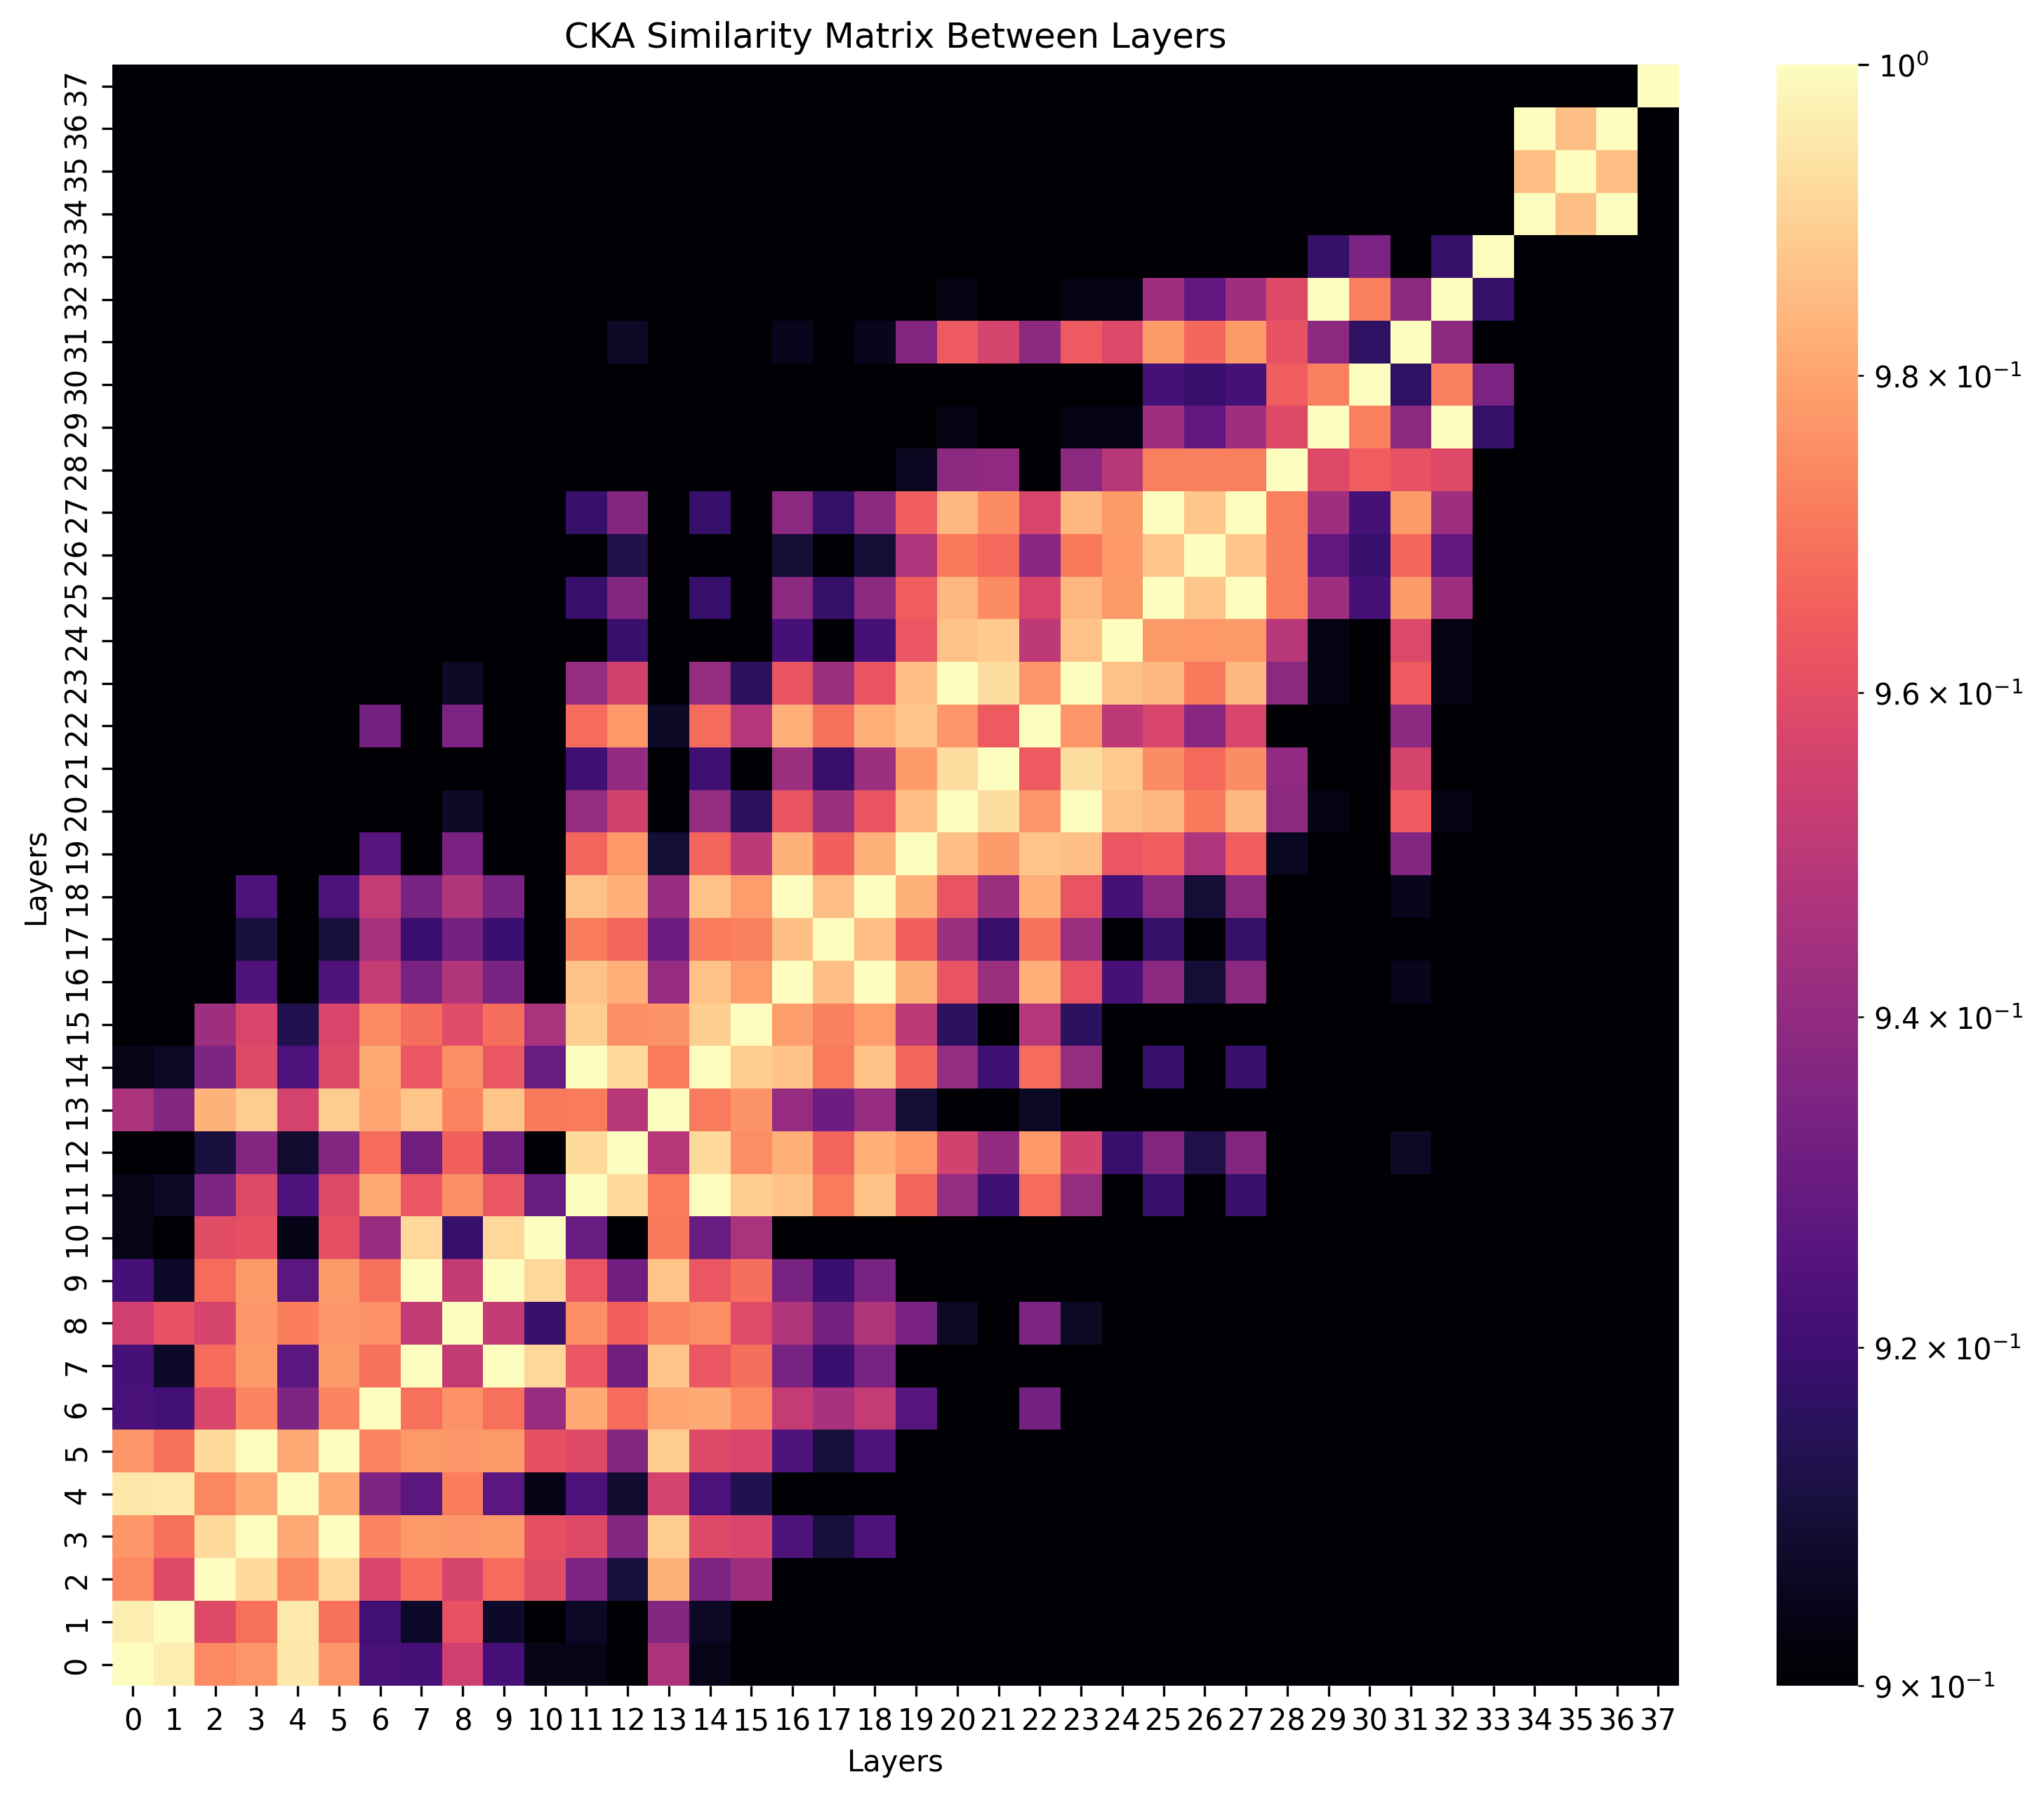

In [17]:
# Now visualize the CKA matrix using seaborn heatmap
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns

def viz_cka_matrix(cka_matrix, layer_names=None):
    fig, ax = plt.subplots(figsize=(12, 10), dpi=300)
    ax = sns.heatmap(cka_matrix, xticklabels=layer_names, yticklabels=layer_names, 
                cmap='magma', annot=False, ax=ax, norm=LogNorm(vmin=0.9, vmax=1))
    ax.set_title('CKA Similarity Matrix Between Layers')
    ax.set_xlabel('Layers')
    ax.set_ylabel('Layers')
    ax.invert_yaxis()  # So that first layer is at the bottom
    return fig, ax

# we reverse the cka_matrix and layer_names so that the first layers are at the bottom-left
fig, ax = viz_cka_matrix(cka_matrix, 
                         layer_names=range(len(cka_matrix)))
plt.show()

In [ ]:
# Extract representations from all layers in execution_order
all_layer_representations = []

for layer_idx, layer in enumerate(execution_order):
    print(f"Processing layer {layer_idx}/{len(execution_order)}: {layer.__class__.__name__}")
    features, labels = get_layer_representations(model, layer, train_loader, device, max_batches=5)
    all_layer_representations.append(features)
    
# Convert to numpy array (list of arrays, each with shape (N, D_i))
all_layer_representations = np.array(all_layer_representations, dtype=object)
print(f"Extracted representations from {len(all_layer_representations)} layers")

In [ ]:
# Extract features from the layer before the final fully connected layer

# Get representations from two layers for comparison (one earlier, and one later layer)
layer = model.resnet18.avgpool
train_features, train_labels = get_layer_representations(model, layer, train_loader, device, max_batches=100)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 2d plot
import umap
umap_model = umap.UMAP(n_components=2, random_state=42)
train_features_2d = umap_model.fit_transform(train_features)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(train_features_2d[:, 0], train_features_2d[:, 1], c=train_labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("UMAP visualization of train features")
plt.show()

In [ ]:
# 2d plot